In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurabh00007/diabetescsv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetescsv' dataset.
Path to dataset files: /kaggle/input/diabetescsv


In [ ]:
import os
df = pd.read_csv(os.path.join(path,"diabetes.csv"))
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.shape

(768, 9)

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.value_counts()

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age  Outcome
12           140      82             43             325      39.2  0.528                     58   1          1
             121      78             17             0        26.5  0.259                     62   0          1
             106      80             0              0        23.6  0.137                     44   0          1
             100      84             33             105      30.0  0.488                     46   0          1
             92       62             7              258      27.6  0.926                     44   1          1
                                                                                                            ..
0            78       88             29             40       36.9  0.434                     21   0          1
             74       52             10             36       27.8  0.269                     22   0          1
             73       0              0              0        21.1  0.342                     25   0          1
             67       76             0              0        45.3  0.194                     46   0          1
             57       60             0              0        21.7  0.735                     67   0          1
Name: count, Length: 768, dtype: int64

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


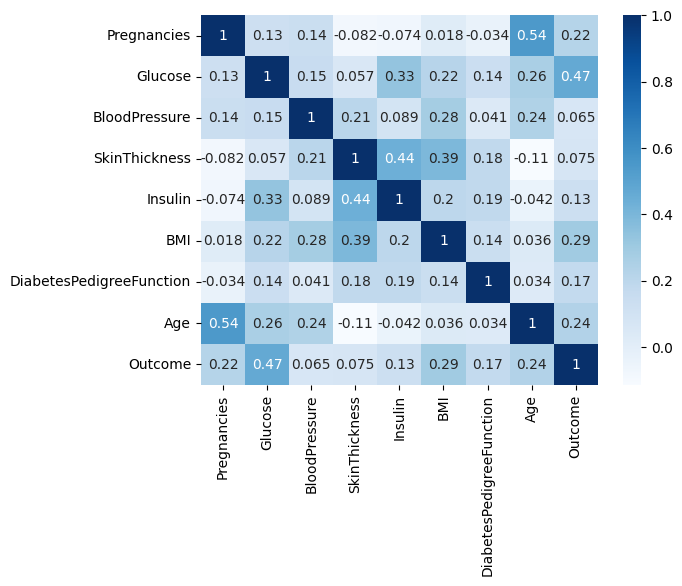

In [ ]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.show()

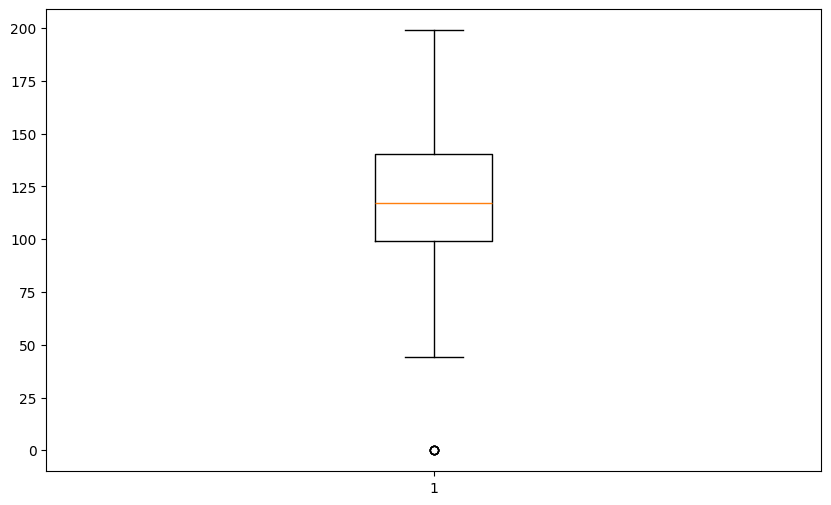

In [ ]:
plt.figure(figsize=(10,6))
plt.boxplot(x=df['Glucose'])
plt.show()

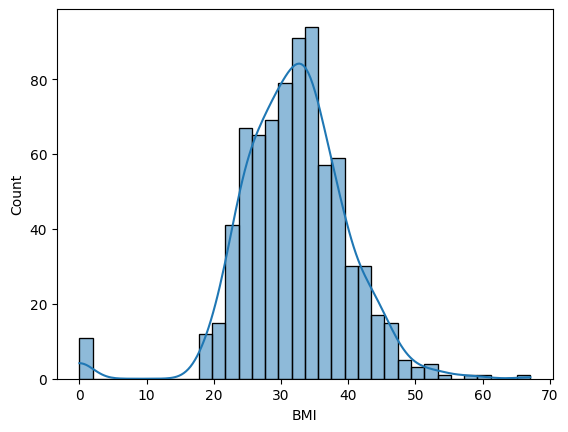

In [ ]:
sns.histplot(df['BMI'],kde = True)
plt.show()

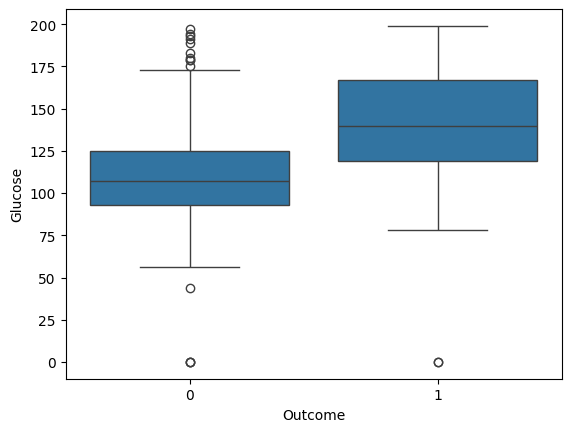

In [ ]:
sns.boxplot(x='Outcome',y='Glucose',data = df)
plt.show()

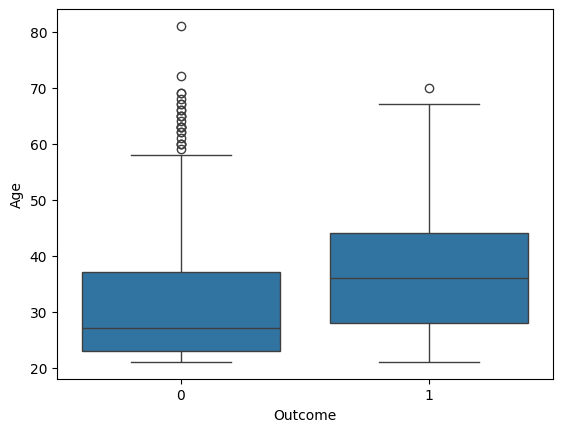

In [ ]:
sns.boxplot(x='Outcome',y='Age',data = df)
plt.show()

In [ ]:
# sns.pairplot(df)
# plt.show()

In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3-Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
5,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
# df['bmiXglucose'] = df['BMI'] * df['Glucose']

In [ ]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train,y_train = sm.fit_resample(X_train,y_train)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
    "SVM" : SVC(),
    "KNN" : KNeighborsClassifier()
}

In [ ]:
results = []

for name, model in models.items():
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)

  acc = accuracy_score(y_test,y_pred)
  prec = precision_score(y_test,y_pred)
  rec = recall_score(y_test,y_pred)
  f1 = f1_score(y_test,y_pred)

  results.append({
      "Model" : name,
      "Accuracy" : acc,
      "Precision" : prec,
      "Recall" : rec,
      "F1 Score" : f1
  })

In [ ]:
results = pd.DataFrame(results)
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.773438   0.585366  0.666667  0.623377
1        Decision Tree  0.734375   0.520833  0.694444  0.595238
2        Random Forest  0.828125   0.675000  0.750000  0.710526
3                  SVM  0.804688   0.634146  0.722222  0.675325
4                  KNN  0.773438   0.568627  0.805556  0.666667


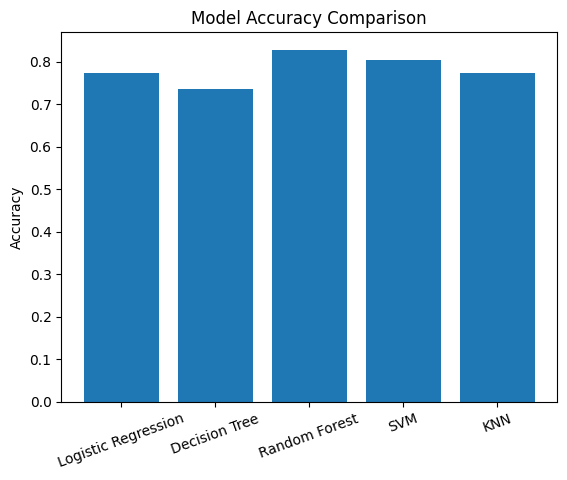

In [ ]:
plt.bar(results['Model'],results['Accuracy'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [ ]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
    "SVM" : SVC(),
    "KNN" : KNeighborsClassifier()
}

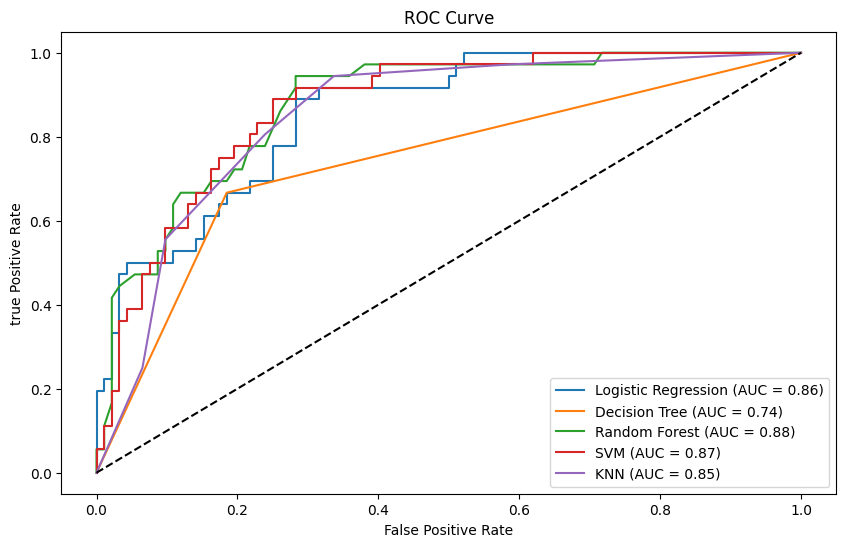

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

for name, model in models.items():
  model.fit(X_train,y_train)

  if hasattr(model,"predict_proba"):
    y_prob = model.predict_proba(X_test)[:,1]
  else:
    y_prob = model.decision_function(X_test)

  fpr,tpr,_ = roc_curve(y_test,y_prob)
  roc_auc = auc(fpr,tpr)

  plt.plot(fpr,tpr,label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("true Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
best_model = RandomForestClassifier()
best_model.fit(X_train,y_train)
pred_rf = best_model.predict(X_test)

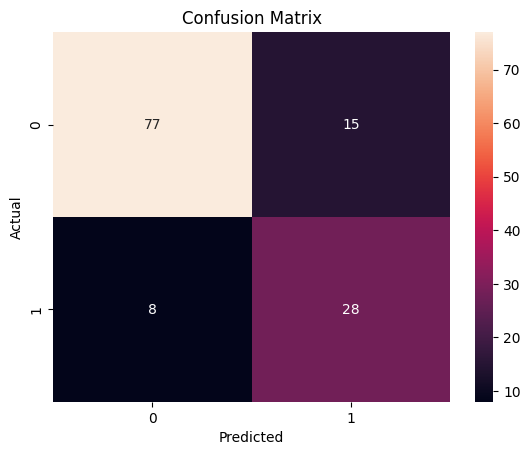

In [ ]:
cm = confusion_matrix(y_test,pred_rf)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.84      0.87        92
           1       0.65      0.78      0.71        36

    accuracy                           0.82       128
   macro avg       0.78      0.81      0.79       128
weighted avg       0.83      0.82      0.82       128



Using Statify

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y)

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train,y_train = sm.fit_resample(X_train,y_train)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
    "SVM" : SVC(),
    "KNN" : KNeighborsClassifier()
}

In [ ]:
results = []

for name, model in models.items():
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)

  acc = accuracy_score(y_test,y_pred)
  prec = precision_score(y_test,y_pred)
  rec = recall_score(y_test,y_pred)
  f1 = f1_score(y_test,y_pred)

  results.append({
      "Model" : name,
      "Accuracy" : acc,
      "Precision" : prec,
      "Recall" : rec,
      "F1 Score" : f1
  })

In [ ]:
results = pd.DataFrame(results)
print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression  0.750000   0.605263   0.575  0.589744
1        Decision Tree  0.648438   0.441860   0.475  0.457831
2        Random Forest  0.757812   0.600000   0.675  0.635294
3                  SVM  0.773438   0.648649   0.600  0.623377
4                  KNN  0.695312   0.509804   0.650  0.571429


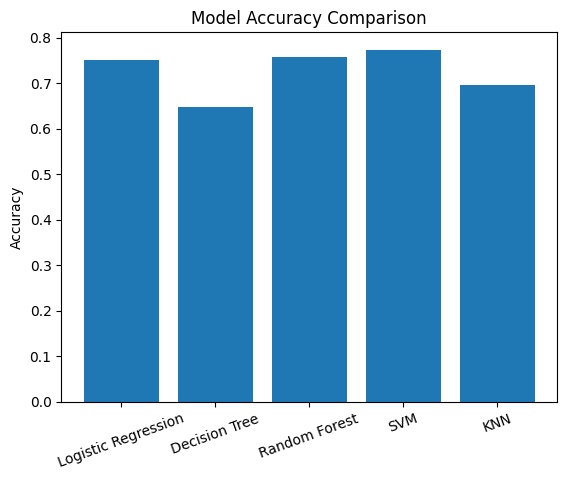

In [ ]:
plt.bar(results['Model'],results['Accuracy'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [ ]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
    "SVM" : SVC(),
    "KNN" : KNeighborsClassifier()
}

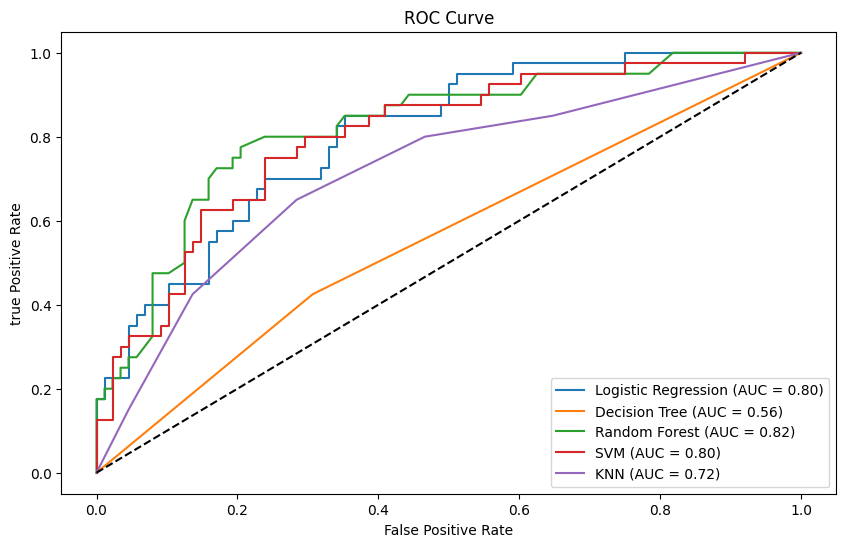

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

for name, model in models.items():
  model.fit(X_train,y_train)

  if hasattr(model,"predict_proba"):
    y_prob = model.predict_proba(X_test)[:,1]
  else:
    y_prob = model.decision_function(X_test)

  fpr,tpr,_ = roc_curve(y_test,y_prob)
  roc_auc = auc(fpr,tpr)

  plt.plot(fpr,tpr,label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("true Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
best_model = RandomForestClassifier()
best_model.fit(X_train,y_train)
pred_rf = best_model.predict(X_test)

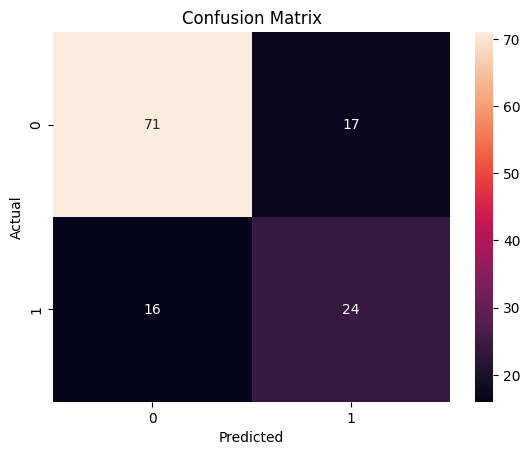

In [ ]:
cm = confusion_matrix(y_test,pred_rf)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81        88
           1       0.59      0.60      0.59        40

    accuracy                           0.74       128
   macro avg       0.70      0.70      0.70       128
weighted avg       0.74      0.74      0.74       128



In [ ]:
import pickle
pickle.dump(best_model,open("Diabetes_model1.pkl","wb"))
pickle.dump(scaler,open("Diabetes_scaler1.pkl","wb"))

In [ ]:
import gradio as gr
import numpy as np
import pickle

model = pickle.load(open("Diabetes_model1.pkl","rb"))
scaler = pickle.load(open("Diabetes_scaler1.pkl","rb"))

def predict_diabetes(pregancies,glucose,bloodpressure,SkinThickness,insulin,bmi,diabetesPedigreefunction,age):
  data = np.array([[pregancies,glucose,bloodpressure,SkinThickness,insulin,bmi,diabetesPedigreefunction,age]])
  data = scaler.transform(data)
  result = model.predict(data)
  return "Diabetic" if result==1 else "Non-Diabetic"

demo = gr.Interface(
    fn=predict_diabetes,
    inputs=["number","number","number","number","number","number","number","number"],
    outputs = "text",
    title = "Diabetes Prediction System"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b6a60a0f2bc23c3f64.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
